# Salinity change
Trying to determine if salinity is changing primarily due to volume fluxes or salt fluxes. 

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import gsw

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-01-zstar-ACCESSyr2-daily-pan01_test_01-986f8f63/output000/*ocean_daily_z_*.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/mom6/archive/panant-ssp126-sofia-daily-expt-2f759912/output000/*ocean_daily_z_*.nc'))

In [3]:
# Time variant variables
def preprocess(ds):
    ds = ds[['volcello','so']].sel(yh=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')

In [4]:
p_C = gsw.p_from_z(-data_C['z_l'], data_C['yh'])
p_M = gsw.p_from_z(-data_M['z_l'], data_M['yh'])

In [5]:
salinity_C = data_C.so
salinity_M = data_M.so

SA_M = gsw.SA_from_SP(salinity_M, p_M, data_M['xh'], data_M['yh'])
SA_C = gsw.SA_from_SP(salinity_C, p_C, data_C['xh'], data_C['yh'])

vol_C = data_C.volcello
vol_M = data_M.volcello

rho_0 = 1035

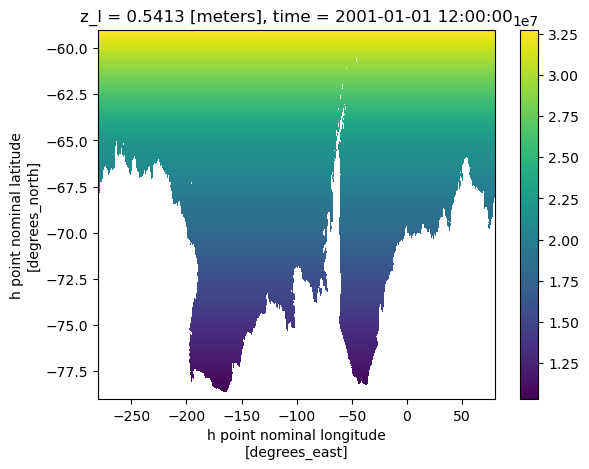

In [6]:
# Doing spatial average
area = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['areacello']
var = data_C.so.isel(time=0).isel(z_l=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [7]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [8]:
depth = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask = (0 * depth).fillna(1)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom6_01')

In [9]:
# Might need total_vol for below but I actually don't think so??
a_cont = (SA_C*vol_C*rho_0)
a_melt = (SA_M*vol_M*rho_0)

# a_cont_test = (SA_C*vol_C*rho_0).where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
# a_melt_test = (SA_M*vol_M*rho_0).where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 

# Total salinity change
salinity_diff = SA_M - SA_C
salinity_diff_total = (a_melt / (vol_M * rho_0)) - (a_cont / (vol_C * rho_0))

# Salinity change due to volume only
salinity_diff_V = (a_cont / (vol_M * rho_0)) - (a_melt / (vol_C * rho_0))

# Salinity change due to salt only
salinity_diff_S = (a_melt / (vol_C * rho_0)) - (a_cont / (vol_C * rho_0))

In [10]:
# Testing averaging after calculation
salinity_diff_avg = salinity_diff.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
salinity_diff_total_avg = salinity_diff_total.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
salinity_diff_V_avg = salinity_diff_V.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
salinity_diff_S_avg = salinity_diff_S.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 

In [11]:
salinity_diff_avg = salinity_diff_avg.load()
salinity_diff_total_avg = salinity_diff_total_avg.load()

In [12]:
salinity_diff_V_avg = salinity_diff_V_avg.load()

In [13]:
salinity_diff_S_avg = salinity_diff_S_avg.load()

Text(0.5, 1.0, 'Salinity change on shelf')

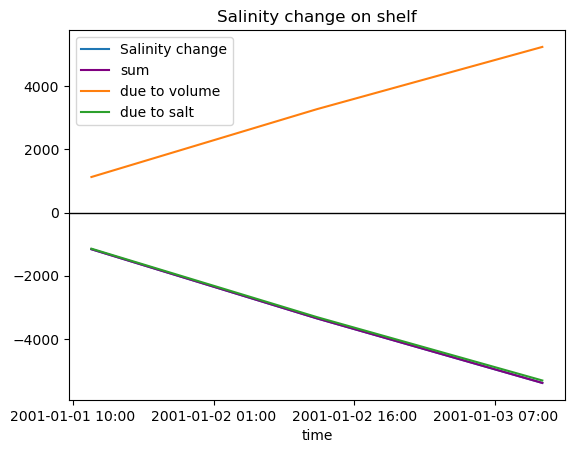

In [14]:
salinity_diff_avg.plot(label = "Salinity change")
salinity_diff_total_avg.plot(label="sum",color='purple')
(salinity_diff_V_avg).plot(label = "due to volume")
salinity_diff_S_avg.plot(label = "due to salt")
#(-salinity_diff_V_avg+salinity_diff_S_avg).plot(label='literal sum')

plt.axhline(0, color='k', linestyle='-', linewidth=1) 
plt.legend()
plt.title("Salinity change on shelf")

Okay so it seems like the order of the averaging really matters here. I will redo below, but I need to go back and convince myself of all the steps. 

### Second attempt

In [15]:
# Doing depth summing prior to calculations. 

total_vol_C = vol_C.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
total_vol_M = vol_M.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 

In [16]:
a_cont = (SA_C*total_vol_C*rho_0).where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
a_melt = (SA_M*total_vol_M*rho_0).where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 

In [17]:
# Total salinity change
salinity_diff = SA_M - SA_C
salinity_diff_total = (a_melt / (total_vol_M * rho_0)) - (a_cont / (total_vol_C * rho_0))

# Salinity change due to volume only
salinity_diff_V = (a_cont / (total_vol_M * rho_0)) - (a_melt / (total_vol_C * rho_0))

# Salinity change due to salt only
salinity_diff_S = (a_melt / (total_vol_M * rho_0)) - (a_cont / (total_vol_C * rho_0))

In [18]:
salinity_diff = salinity_diff.load()
salinity_diff_total = salinity_diff_total.load()

In [19]:
salinity_diff_V = salinity_diff_V.load()
salinity_diff_S = salinity_diff_S.load()

Text(0.5, 1.0, 'Salinity change on shelf')

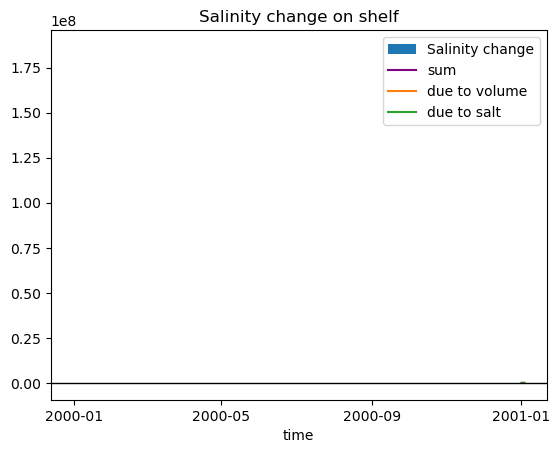

In [20]:
salinity_diff.plot(label = "Salinity change")
salinity_diff_total.plot(label="sum",color='purple')
(salinity_diff_V).plot(label = "due to volume")
salinity_diff_S.plot(label = "due to salt")

plt.axhline(0, color='k', linestyle='-', linewidth=1) 
plt.legend()
plt.title("Salinity change on shelf")

In [21]:
salinity_diff

<xarray.DataArray 'so' (time: 3, z_l: 75, yh: 460, xh: 3600)> Size: 3GB
array([[[[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [-2.59490672e-03, -1.38369480e-03,  7.66589962e-05, ...,
          -2.99353330e-03, -3.36149645e-03, -2.95903681e-03],
         [-1.18054817e-03, -1.03489618e-04,  7.01429674e-04, ...,
          -2.90537488e-03, -2.35343033e-03, -1.83214937e-03],
         [ 2.26143921e-04,  7.28260128e-04,  9.12241688e-04, ...,
          -6.47768144e-04, -5.36612670e-04, -2.87471076e-04]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
...
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]]]])
Coordinates:
  * time     (time) object 24B 2001-01-01 12:00:00 ... 2001-01-03 12:00:00
  * z_l      (z_l) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yh       (yh) float64 4kB -79.0 -78.95 -78.91 ... -59.14 -59.08 -59.03
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95

## Third attempt: Success!
I think the trick is that I need to do all of my averaging before any of the salinity equations. So keep everything with full depth/space when calculating the individual terms, but then every term should be shelf and depth averaged before being used in the salinity equations.

Repeating cells so that I can see the full method all together:

In [23]:
p_C = gsw.p_from_z(-data_C['z_l'], data_C['yh'])
p_M = gsw.p_from_z(-data_M['z_l'], data_M['yh'])

salinity_C = data_C.so
salinity_M = data_M.so

SA_M = gsw.SA_from_SP(salinity_M, p_M, data_M['xh'], data_M['yh']) # testing with p_C
SA_C = gsw.SA_from_SP(salinity_C, p_C, data_C['xh'], data_C['yh'])

vol_C = data_C.volcello
vol_M = data_M.volcello

rho_0 = 1035

In [27]:
total_vol_C = vol_C.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 
total_vol_M = vol_M.where(shelf_mask ==1).sum(['xh', 'yh', 'z_l']) 

In [28]:
# g/kg * m3 * kg/m3 gives grams of salt on the shelf
a_shelf_C = ((SA_C * vol_C).where(shelf_mask==1) * rho_0).sum(['xh','yh','z_l']) 
a_shelf_M = ((SA_M * vol_M).where(shelf_mask==1) * rho_0).sum(['xh','yh','z_l'])

In [29]:
salinity_diff = a_shelf_M/total_vol_M - a_shelf_C/total_vol_C

salinity_diff_V = a_shelf_C/total_vol_M - a_shelf_C/total_vol_C

salinity_diff_S = a_shelf_M/total_vol_C - a_shelf_C/total_vol_C

In [30]:
salinity_diff = salinity_diff.load()
salinity_diff_V = salinity_diff_V.load()
salinity_diff_S = salinity_diff_S.load()

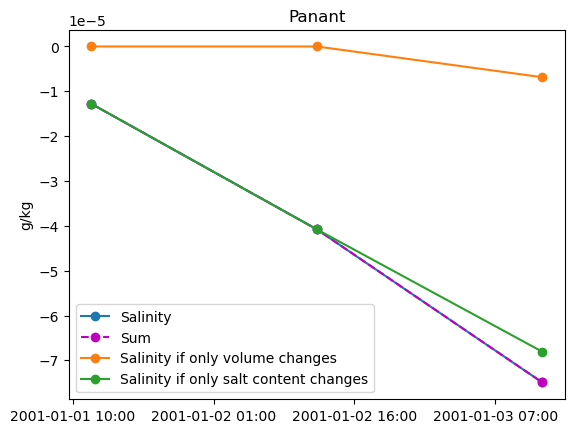

In [31]:
(salinity_diff/rho_0).plot(label='Salinity', marker='o')
((salinity_diff_S+salinity_diff_V)/rho_0).plot(c='m', linestyle='--', label='Sum', marker='o')
(salinity_diff_V/rho_0).plot(label='Salinity if only volume changes', marker='o')
(salinity_diff_S/rho_0).plot(label='Salinity if only salt content changes', marker='o')
plt.legend()
plt.xlabel(''); plt.ylabel('g/kg'); plt.title('Panant');